
# How a Model Learns Using Derivatives (Gradient Descent)
### California Housing Dataset — Visual Learning Over Epochs

This notebook **intentionally starts with a very bad model**
and shows **slow improvement over epochs** so you can clearly see learning.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler



## 1. Load California Housing Data (Single Feature)
We use **Median Income** to predict **House Price**.


Text(0.5, 1.0, 'Training Data')

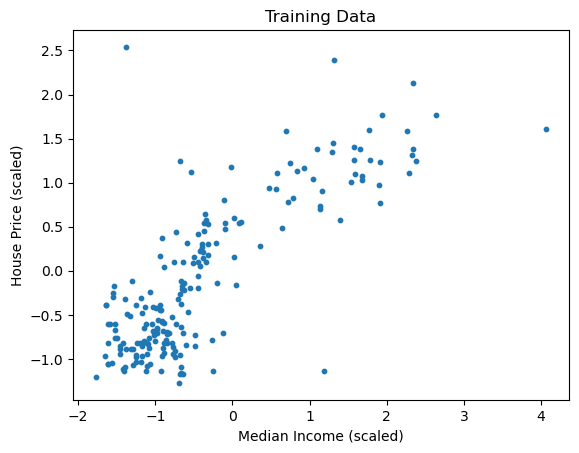

In [ ]:

data = fetch_california_housing()
X = data.data[:, data.feature_names.index("MedInc")]
y = data.target

# Create a DataFrame for easy viewing
df = pd.DataFrame({
    "MedianIncome (MedInc)": X.flatten(),
    "HousePrice (Target)": y
})

# Show first 10 rows
df.head(10)
display(df.head(10))

X = X.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# small subset for visualization
X = X[:200]
y = y[:200]

plt.scatter(X, y, s=10)
plt.xlabel("Median Income (scaled)")
plt.ylabel("House Price (scaled)")
plt.title("Training Data")
plt.show()



## 2. Model Initialization (Very Bad Start)
We **intentionally** start with:
- w = 0
- b = 0


In [39]:

w = 0.0
b = 0.0



## 3. Loss Function (Mean Squared Error)


In [40]:

def loss(y, y_hat):
    return np.mean((y - y_hat) ** 2)



## 4. Epoch 0 — Bad Prediction (Before Learning)


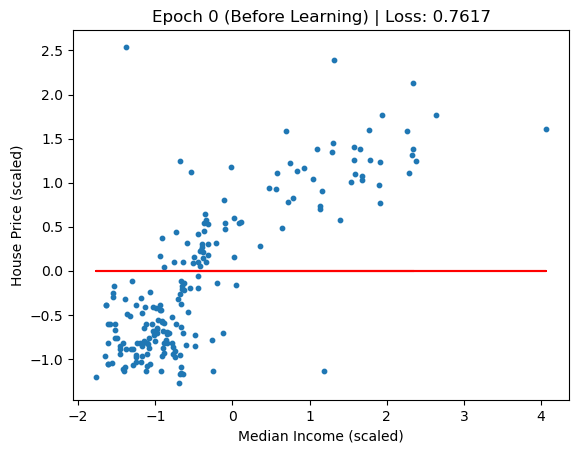

In [41]:

y_hat = w * X.flatten() + b

plt.scatter(X, y, s=10)
plt.plot(X, y_hat, color='red')
plt.title(f"Epoch 0 (Before Learning) | Loss: {loss(y, y_hat):.4f}")
plt.xlabel("Median Income (scaled)")
plt.ylabel("House Price (scaled)")
plt.show()



## 5. Gradient Descent — Slow Learning
Small learning rate so early epochs still look bad.


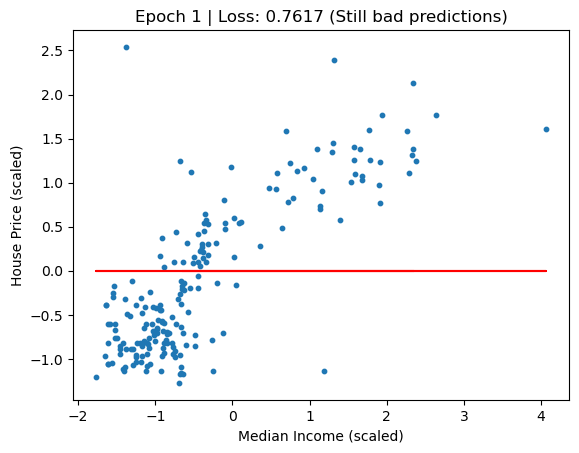

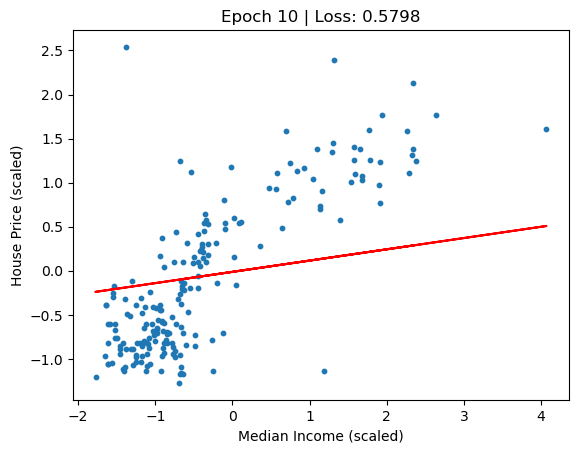

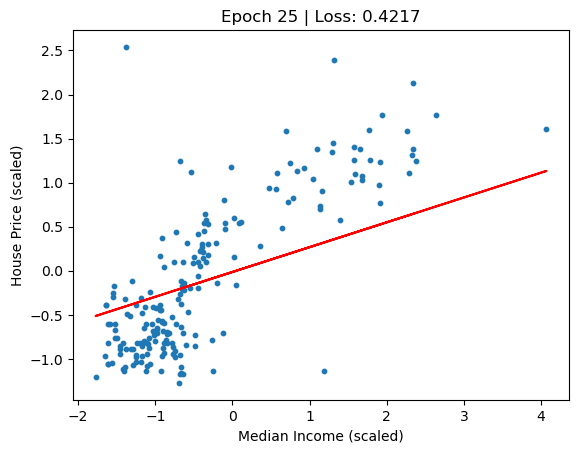

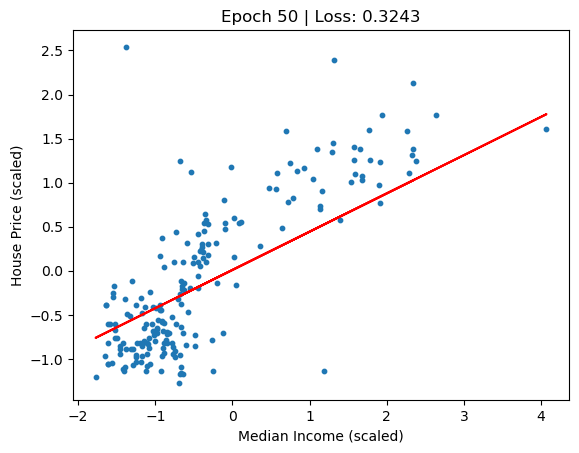

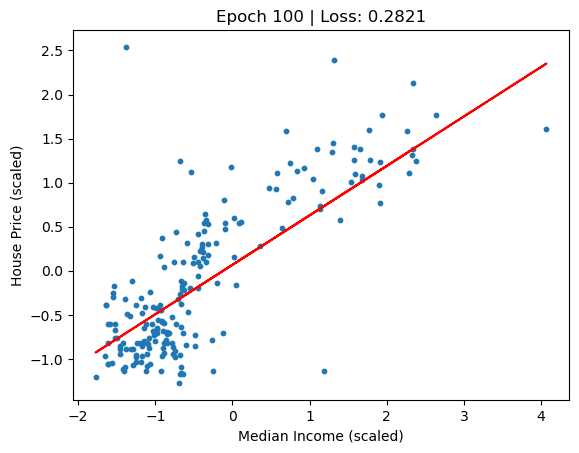

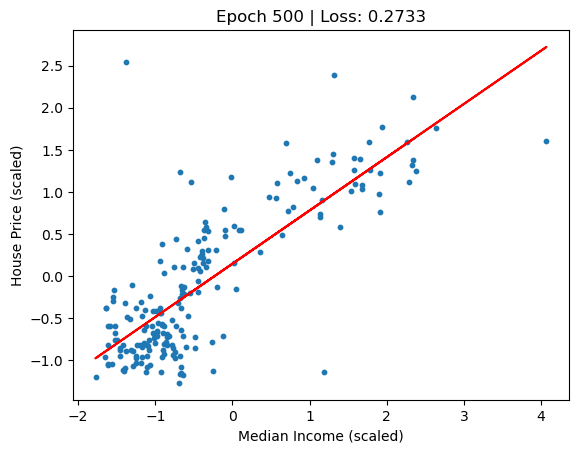

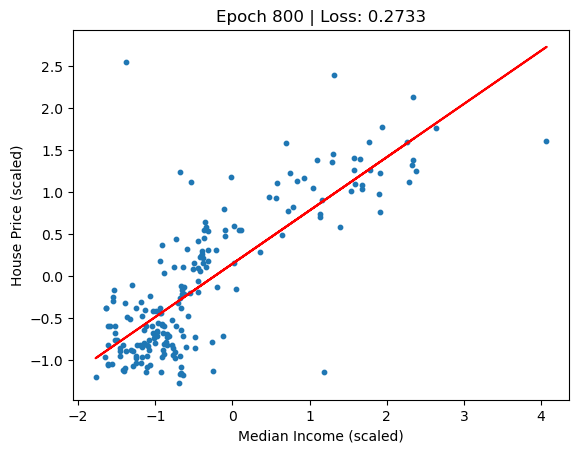

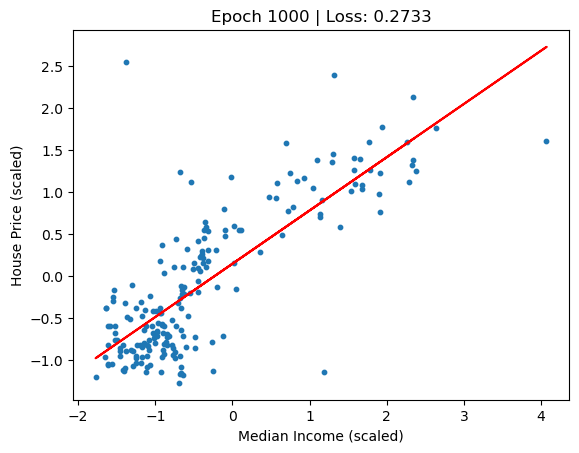

In [42]:

lr = 0.01   # intentionally small
epochs = 1000

for epoch in range(1, epochs + 1):
    y_hat = w * X.flatten() + b

    # derivatives
    dw = -2 * np.mean(X.flatten() * (y - y_hat))
    db = -2 * np.mean(y - y_hat)

    # update
    w -= lr * dw
    b -= lr * db
    graph_display_values = [1, 10, 25, 50, 100, 500, 800,  1000]
    if epoch in graph_display_values:
        plt.scatter(X, y, s=10)
        plt.plot(X, y_hat, color='red')

        if epoch <= 8:
            note = " (Still bad predictions)"
        else:
            note = ""  
    
        plt.title(f"Epoch {epoch} | Loss: {loss(y, y_hat):.4f}{note}")
        plt.xlabel("Median Income (scaled)")
        plt.ylabel("House Price (scaled)")
        plt.show()



## 6. What This Shows Clearly

- Epoch 0: Model is **completely wrong**
- First few epochs: Model improves, but still bad
- Later epochs: Loss decreases steadily
- Learning happens because of **derivatives**
